In [32]:
import numpy as np
import matplotlib.pyplot as plt


def bar_parallel(N, K, partitions, dgro_dqn, dgro_greedy, rapid, perigee):
    """
    Function to create a grouped bar chart comparing different algorithms.
    
    Parameters:
    - N: Number of nodes
    - K: Degree of the graph
    - partitions: List of partition sizes
    - dgro_dqn: List of diameters for DGRO-DQN
    - dgro_greedy: List of diameters for DGRO-GREEDY
    - rapid: List of diameters for RAPID
    - perigee: List of diameters for Perigee
    """
    # Create bar width and positions
    x = np.arange(len(partitions))
    width = 0.2

    # Plot the grouped bar chart
    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width, dgro_dqn, width, label='DGRO-DQN')
    bars2 = plt.bar(x, dgro_greedy, width, label='DGRO-GREEDY')
    bars3 = plt.bar(x + 2 * width, rapid, width, label='RAPID')
    bars4 = plt.bar(x + width, perigee, width, label='Perigee')

    # Add text labels on top of the bars
    for bar in bars1:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, 
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, 
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)
    for bar in bars3:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, 
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)
    for bar in bars4:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, 
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)

    # Labels and title
    plt.xlabel("Number of Partitions in DQN", fontdict={'fontsize': 12})
    plt.ylabel("Diameter", fontdict={'fontsize': 12})
    plt.title(f"Diameter Comparison: DGRO-DQN vs DGRO-GREEDY vs RAPID\nN={N}, Degree={K}", fontsize=14)
    plt.xticks(x, partitions, fontsize=12)
    plt.legend(fontsize=12, loc='lower center', ncols=4)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"figures/parallel/diameter_comparison_N={N}_K={K}.png", dpi=300, bbox_inches='tight')
    plt.show()

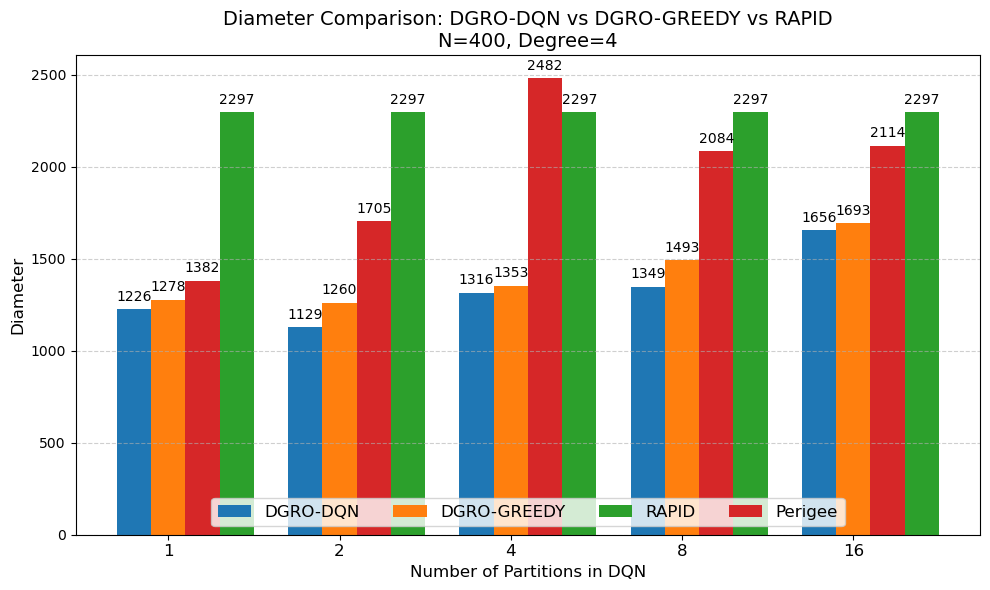

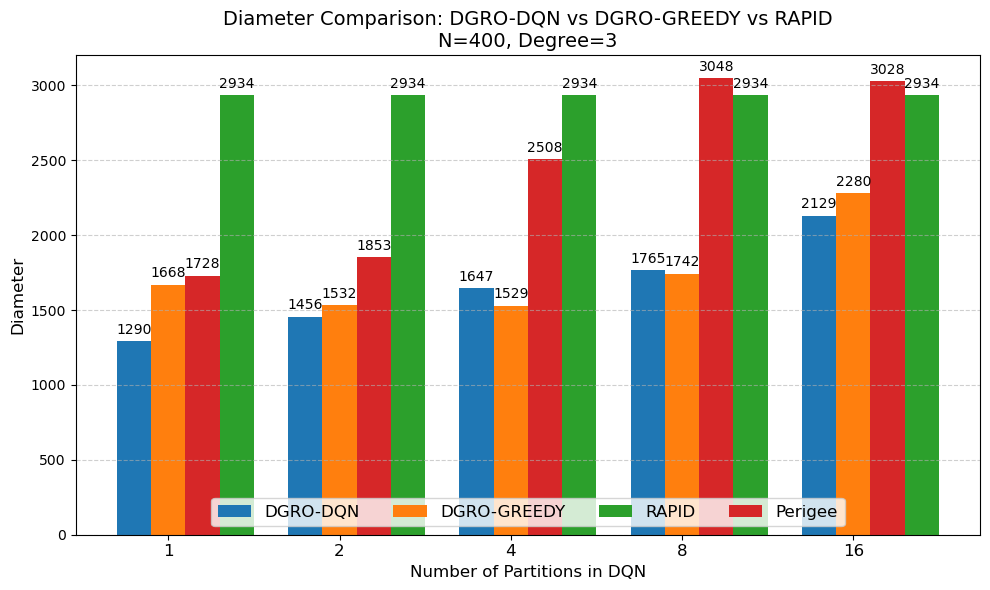

In [33]:
import numpy as np
import matplotlib.pyplot as plt


# Define data
partitions = ["1", "2", "4", "8", "16"]
dgro_dqn = [1226, 1129, 1316, 1349, 1656]
dgro_greedy = [1278, 1260, 1353, 1493, 1693]
rapid = [2297] * len(partitions)  # Repeat for comparison
perigee = [1382, 1705, 2482, 2084, 2114]
bar_parallel(400, 4, partitions, dgro_dqn, dgro_greedy, rapid, perigee)

# Define data
partitions = ["1", "2", "4", "8", "16"]
dgro_dqn = [1290, 1456, 1647, 1765, 2129]
dgro_greedy = [1668, 1532, 1529, 1742, 2280]
rapid = [2934] * len(partitions)
perigee = [1728, 1853, 2508, 3048, 3028]
bar_parallel(400, 3, partitions, dgro_dqn, dgro_greedy, rapid, perigee)


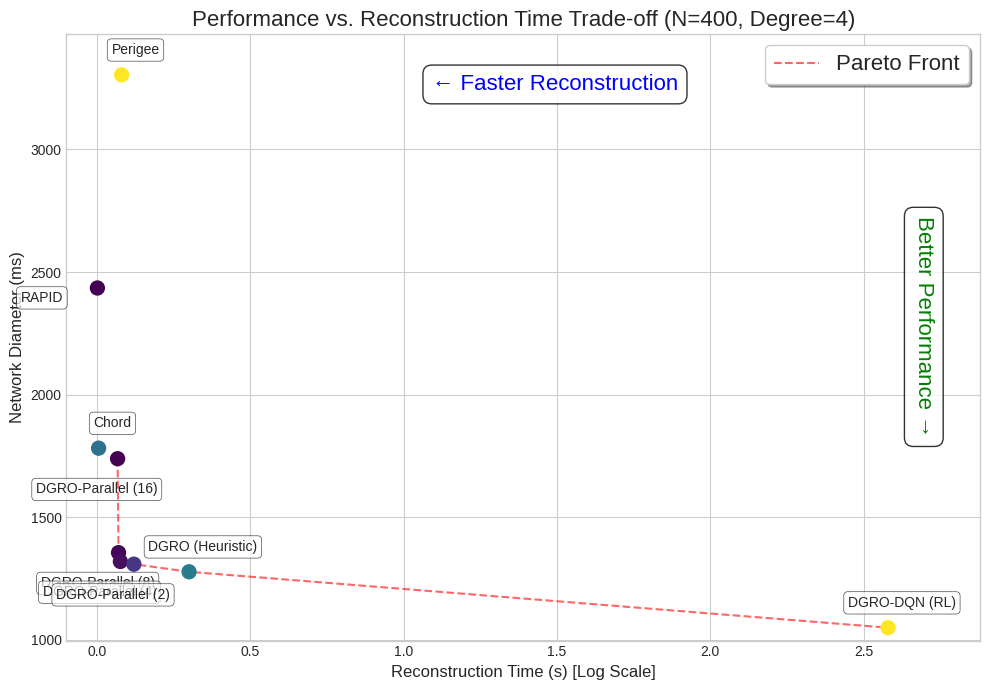

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data From Your Paper ---
# Each entry is a tuple: (Method Name, Time (s), Diameter (ms))
data = [
    ("DGRO-Parallel (16)", 0.067, 1739),
    ("DGRO-Parallel (8)", 0.070, 1356),
    ("DGRO-Parallel (4)", 0.076, 1320),
    ("DGRO-Parallel (2)", 0.12, 1309),
    ("DGRO (Heuristic)", 0.30, 1278),
    ("DGRO-DQN (RL)", 2.58, 1050),
]


data_baseline = [
    ("RAPID", 0.001, 2435),
    # ("NN", 0.003, 7423),
    ("Perigee", 0.08, 3304),
    ("Chord", 0.005, 1782),
]
# Unzip the data into separate lists for plotting
labels = [d[0] for d in data]
times = [d[1] for d in data]
diameters = [d[2] for d in data]

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid') # Use a clean, professional style
fig, ax = plt.subplots(figsize=(10, 7))

# Create the scatter plot of the data points
# We use distinct markers and colors to differentiate the methods
scatter = ax.scatter(times, diameters, c=np.log10(times), cmap='viridis', s=100, zorder=5)

# Draw a line connecting the points to emphasize the Pareto front
ax.plot(times, diameters, 'r--', alpha=0.6, zorder=4, label='Pareto Front')

# --- Annotations and Labels ---
# Add text labels for each point for clarity
for i, label in enumerate(labels):
    # Adjust text position for better readability
    x_offset = 10 if "Parallel" not in label else -15
    y_offset = 15 if "Parallel" not in label else -25
    if label == "RAPID":
      x_offset = -40
      y_offset = -10

    ax.annotate(
        label,
        (times[i], diameters[i]),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha='center',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.7)
    )
ax.set_xlim(-0.1, max(times) +0.3)
ax.set_ylim(min(diameters) * 0.95, 3304 * 1.05)
data = [
    ("RAPID", 0.001, 2435),
    ("NN", 0.003, 7423),
    ("Perigee", 0.08, 3304),
    ("Chord", 0.005, 1782),
]
# Unzip the data into separate lists for plotting
labels = [d[0] for d in data]
times = [d[1] for d in data]
diameters = [d[2] for d in data]

# --- Plotting ---
# plt.style.use('seaborn-v0_8-whitegrid') # Use a clean, professional style
# fig, ax = plt.subplots(figsize=(10, 7))

# Create the scatter plot of the data points
# We use distinct markers and colors to differentiate the methods
scatter = ax.scatter(times, diameters, c=np.log10(times), cmap='viridis', s=100, zorder=5)

# Draw a line connecting the points to emphasize the Pareto front
# ax.plot(times, diameters, 'r--', alpha=0.6, zorder=4, label='Pareto Front')

# --- Annotations and Labels ---
# Add text labels for each point for clarity
for i, label in enumerate(labels):
    # Adjust text position for better readability
    x_offset = 10 if "Parallel" not in label else -15
    y_offset = 15 if "Parallel" not in label else -25
    if label == "RAPID":
      x_offset = -40
      y_offset = -10

    ax.annotate(
        label,
        (times[i], diameters[i]),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha='center',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.7)
    )

# --- Formatting the Plot ---
# ax.set_xscale('log') # Use a logarithmic scale for the time axis

# Set titles and labels
ax.set_title('Performance vs. Reconstruction Time Trade-off (N=400, Degree=4)', fontsize=16)
ax.set_xlabel('Reconstruction Time (s) [Log Scale]', fontsize=12)
ax.set_ylabel('Network Diameter (ms)', fontsize=12)

# Set axis limits to provide some padding
# ax.set_xlim(min(times) * 0.5, max(times) * 2)


# Add a legend
ax.legend(loc='upper right', fontsize=16, frameon=True, shadow=True)

# Add a helpful annotation explaining the trade-off
ax.text(
    0.95, 0.7,
    'Better Performance →',
    verticalalignment='top', horizontalalignment='right',
    transform=ax.transAxes,
    color='green', fontsize=16, rotation=270,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8)
)
ax.text(
    0.4, 0.9,
    '← Faster Reconstruction',
    verticalalignment='bottom', horizontalalignment='left',
    transform=ax.transAxes,
    color='blue', fontsize=16,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8)
)


# Show the plot
plt.tight_layout()
plt.show()

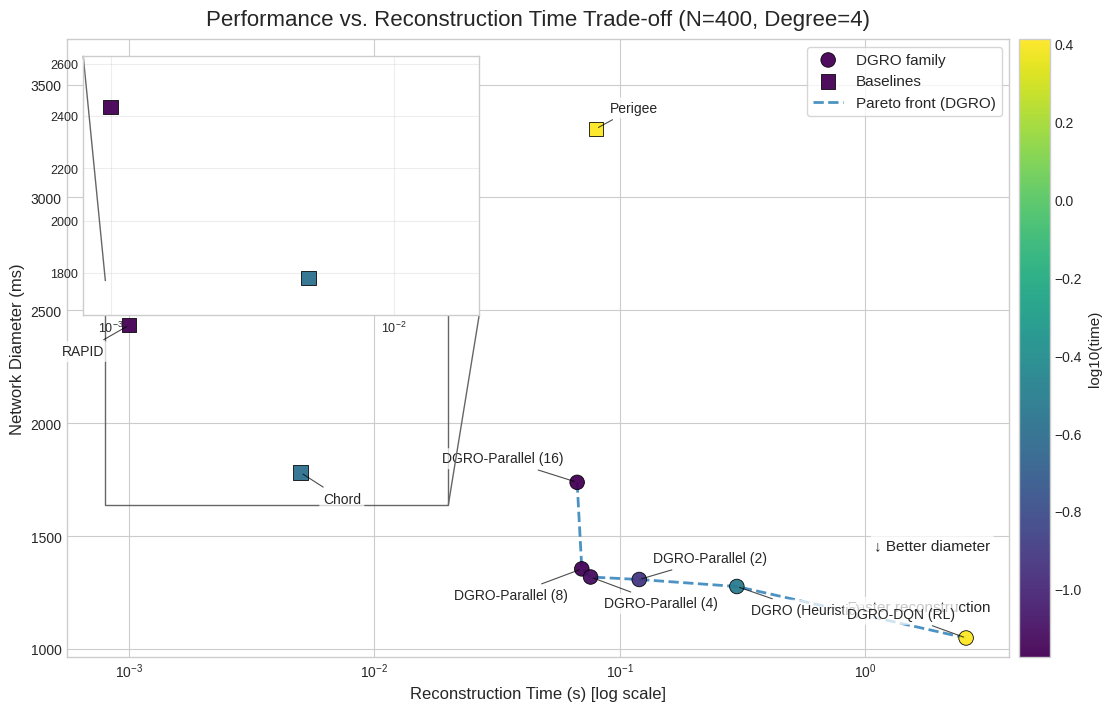

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ---------------- Data ----------------
dgros = [
    ("DGRO-Parallel (16)", 0.067, 1739),
    ("DGRO-Parallel (8)",  0.070, 1356),
    ("DGRO-Parallel (4)",  0.076, 1320),
    ("DGRO-Parallel (2)",  0.120, 1309),
    ("DGRO (Heuristic)",   0.300, 1278),
    ("DGRO-DQN (RL)",      2.580, 1050),
]

baselines = [
    ("RAPID",   0.001, 2435),
    ("Chord",   0.005, 1782),
    ("Perigee", 0.080, 3304),
    # ("NN",    0.003, 7423),  # 如果要放开，把 y 轴上限调大或单独 inset
]

# Pareto front（按 time 排序后连线）
pareto = sorted(dgros, key=lambda x: x[1])
pareto_t = [x[1] for x in pareto]
pareto_d = [x[2] for x in pareto]

# ---------------- Plot ----------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

def scatter_group(ax, data, marker, label, z=3):
    t = np.array([x[1] for x in data], dtype=float)
    d = np.array([x[2] for x in data], dtype=float)
    sc = ax.scatter(
        t, d,
        s=110,
        marker=marker,
        c=np.log10(t),
        cmap="viridis",
        edgecolors="black",
        linewidths=0.6,
        alpha=0.95,
        zorder=z,
        label=label
    )
    return t, d, sc

t1, d1, sc1 = scatter_group(ax, dgros, marker="o", label="DGRO family", z=4)
t2, d2, sc2 = scatter_group(ax, baselines, marker="s", label="Baselines", z=4)

# Pareto front line
ax.plot(pareto_t, pareto_d, linestyle="--", linewidth=2, alpha=0.8, zorder=2, label="Pareto front (DGRO)")

# Log x-scale to un-squeeze the left cluster
ax.set_xscale("log")

# Axis limits with padding (log scale: multiply/divide is nicer than +/-)
all_t = np.array([x[1] for x in dgros + baselines], dtype=float)
all_d = np.array([x[2] for x in dgros + baselines], dtype=float)
ax.set_xlim(all_t.min() / 1.8, all_t.max() * 1.5)
ax.set_ylim(all_d.min() * 0.92, all_d.max() * 1.12)

ax.set_title("Performance vs. Reconstruction Time Trade-off (N=400, Degree=4)", fontsize=16, pad=10)
ax.set_xlabel("Reconstruction Time (s) [log scale]", fontsize=12)
ax.set_ylabel("Network Diameter (ms)", fontsize=12)

# Colorbar (log10(time))
cbar = fig.colorbar(sc1, ax=ax, pad=0.01)
cbar.set_label("log10(time)", fontsize=11)

# ---------------- Annotations ----------------
def annotate_points(ax, data, offsets):
    """
    offsets: dict(name -> (dx, dy)) in points
    """
    for name, t, d in data:
        dx, dy = offsets.get(name, (10, 10))
        ax.annotate(
            name, xy=(t, d),
            xytext=(dx, dy), textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.7),
            zorder=10
        )

# 手工给几个最容易撞车的点更大偏移（你也可以继续微调）
offsets_main = {
    "RAPID": (-18, -14),
    "Chord": (16, -14),
    "Perigee": (10, 10),
    "DGRO-DQN (RL)": (-8, 12),
    "DGRO (Heuristic)": (10, -12),
    "DGRO-Parallel (2)": (10, 10),
    "DGRO-Parallel (4)": (10, -14),
    "DGRO-Parallel (8)": (-10, -14),
    "DGRO-Parallel (16)": (-10, 12),
}

annotate_points(ax, dgros, offsets_main)
annotate_points(ax, baselines, offsets_main)

# ---------------- Inset zoom for small-time region ----------------
# 放大 0.0008~0.02 秒区间（根据你的点分布可调整）
axins = inset_axes(ax, width="42%", height="42%", loc="upper left", borderpad=1.2)
axins.set_xscale("log")

# 画同样的点到 inset
scatter_group(axins, dgros, marker="o", label=None, z=4)
scatter_group(axins, baselines, marker="s", label=None, z=4)

axins.plot(pareto_t, pareto_d, linestyle="--", linewidth=1.6, alpha=0.8, zorder=2)

axins.set_xlim(8e-4, 2e-2)
# y 范围按这段区间内的点自动给一点 padding
mask = (all_t >= 8e-4) & (all_t <= 2e-2)
ymin = all_d[mask].min() if mask.any() else all_d.min()
ymax = all_d[mask].max() if mask.any() else all_d.max()
axins.set_ylim(ymin * 0.92, ymax * 1.08)

axins.tick_params(labelsize=9)
axins.grid(True, alpha=0.35)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

# ---------------- Legend & extras ----------------
ax.legend(loc="upper right", fontsize=11, frameon=True)

# 方向提示（更克制一点，避免抢戏）
ax.text(
    0.98, 0.08, "← Faster reconstruction",
    transform=ax.transAxes, ha="right", va="center", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
)
ax.text(
    0.98, 0.18, "↓ Better diameter",
    transform=ax.transAxes, ha="right", va="center", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
)

plt.show()


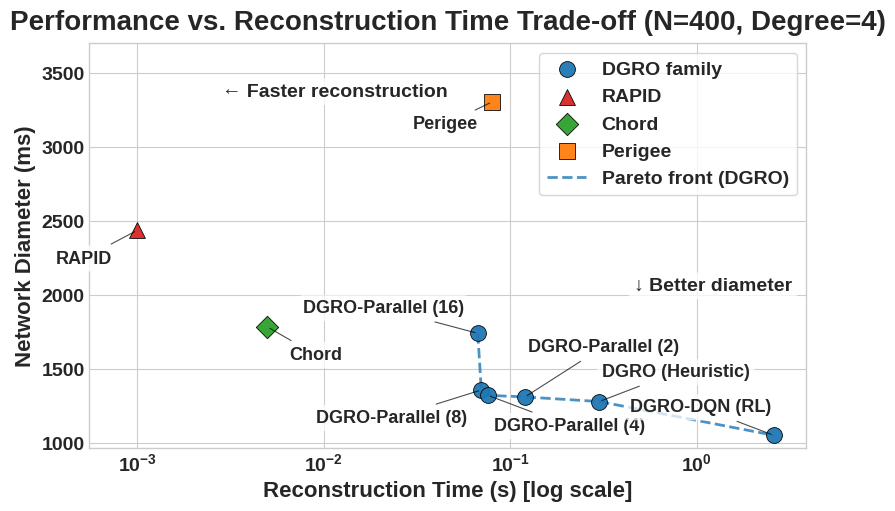

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.size': 14,
})

# ---------------- Data ----------------
dgros = [
    ("DGRO-Parallel (16)", 0.067, 1739),
    ("DGRO-Parallel (8)",  0.070, 1356),
    ("DGRO-Parallel (4)",  0.076, 1320),
    ("DGRO-Parallel (2)",  0.120, 1309),
    ("DGRO (Heuristic)",   0.300, 1278),
    ("DGRO-DQN (RL)",      2.580, 1050),
]

baselines = [
    ("RAPID",   0.001, 2435),
    ("Chord",   0.005, 1782),
    ("Perigee", 0.080, 3304),
    # ("NN",    0.003, 7423),  # 如果要放开，把 y 轴上限调大或单独 inset
]

# Pareto front（按 time 排序后连线）
pareto = sorted(dgros, key=lambda x: x[1])
pareto_t = [x[1] for x in pareto]
pareto_d = [x[2] for x in pareto]

# ---------------- Plot ----------------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# DGRO family: all use the same color
dgro_color = "#1f77b4"
t1 = np.array([x[1] for x in dgros], dtype=float)
d1 = np.array([x[2] for x in dgros], dtype=float)
ax.scatter(t1, d1, s=130, marker="o", color=dgro_color,
           edgecolors="black", linewidths=0.6, alpha=0.95, zorder=4, label="DGRO family")

# Baselines: each method gets a distinct color & marker
baseline_styles = {
    "RAPID":   {"color": "#d62728", "marker": "^"},
    "Chord":   {"color": "#2ca02c", "marker": "D"},
    "Perigee": {"color": "#ff7f0e", "marker": "s"},
}
for name, t, d in baselines:
    sty = baseline_styles[name]
    ax.scatter(t, d, s=130, marker=sty["marker"], color=sty["color"],
               edgecolors="black", linewidths=0.6, alpha=0.95, zorder=4, label=name)

# Pareto front line
ax.plot(pareto_t, pareto_d, linestyle="--", linewidth=2, alpha=0.8, zorder=2, label="Pareto front (DGRO)")

# Log x-scale to un-squeeze the left cluster
ax.set_xscale("log")

# Axis limits with padding (log scale: multiply/divide is nicer than +/-)
all_t = np.array([x[1] for x in dgros + baselines], dtype=float)
all_d = np.array([x[2] for x in dgros + baselines], dtype=float)
ax.set_xlim(all_t.min() / 1.8, all_t.max() * 1.5)
ax.set_ylim(all_d.min() * 0.92, all_d.max() * 1.12)

ax.set_title("Performance vs. Reconstruction Time Trade-off (N=400, Degree=4)", fontsize=20, fontweight='bold', pad=10)
ax.set_xlabel("Reconstruction Time (s) [log scale]", fontsize=16, fontweight='bold')
ax.set_ylabel("Network Diameter (ms)", fontsize=16, fontweight='bold')

# ---------------- Annotations ----------------
def annotate_points(ax, data, offsets):
    """
    offsets: dict(name -> (dx, dy)) in points
    """
    for name, t, d in data:
        dx, dy = offsets.get(name, (10, 10))
        ax.annotate(
            name, xy=(t, d),
            xytext=(dx, dy), textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.7),
            zorder=10
        )

# 手工给几个最容易撞车的点更大偏移（你也可以继续微调）
offsets_main = {
    "RAPID": (-18, -14),
    "Chord": (16, -14),
    "Perigee": (-10, -10),
    "DGRO-DQN (RL)": (-2, 14),
    "DGRO (Heuristic)": (2, 15),
    "DGRO-Parallel (2)": (2, 30),
    "DGRO-Parallel (4)": (4, -16),
    "DGRO-Parallel (8)": (-10, -14),
    "DGRO-Parallel (16)": (-10, 12),
}

annotate_points(ax, dgros, offsets_main)
annotate_points(ax, baselines, offsets_main)

# ---------------- Legend & extras ----------------
ax.legend(loc="upper right", fontsize=13, frameon=True, prop={'weight': 'bold'})

# 方向提示（更克制一点，避免抢戏）
ax.text(
    0.5, 0.88, "← Faster reconstruction",
    transform=ax.transAxes, ha="right", va="center", fontsize=14, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
)
ax.text(
    0.98, 0.4, "↓ Better diameter",
    transform=ax.transAxes, ha="right", va="center", fontsize=14, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75)
)

# plt.show()
plt.savefig("pareto.pdf")
